In [1]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:

import pandas as pd
from sklearn.model_selection import train_test_split
df = pd.read_csv('mnist_train.csv')
t = df.iloc[:, 0] # the labels column
x = df.iloc[:, 1:] # the pixels columns
x_train_val , x_test, y_train_val, y_test = train_test_split(x , t , test_size=0.20, random_state=42 , stratify=t)
# Adding stratify=y ensures the split isn't random in a way that accidentally leaves all the "9s" in the test set

x_train, x_val, y_train, y_val = train_test_split(x_train_val , y_train_val , test_size=0.25, random_state=42 , stratify=y_train_val)

#check the splitting done correctly
print(f"Training shapes: {x_train.shape , y_train.shape}")
print(f"Validation shapes: {x_val.shape , y_val.shape}")
print(f"Testing shapes: {x_test.shape , y_test.shape}")


x_train = x_train/255.0
x_val = x_val/255.0
x_test = x_test/255.0

# Convert to PyTorch tensors el pictures el kter htt2sm batches

train_features = torch.tensor(x_train.values , dtype=torch.float32)
train_labels = torch.tensor(y_train.values , dtype=torch.long)

train_dataset = TensorDataset(train_features, train_labels)

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True  # Shuffle the training data 
                              )

val_features = torch.tensor(x_val.values , dtype=torch.float32)
val_labels = torch.tensor(y_val.values , dtype=torch.long)
val_dataset = TensorDataset(val_features, val_labels)
val_dataloader = DataLoader(val_dataset, batch_size=64)

test_features = torch.tensor(x_test.values , dtype=torch.float32)
test_labels = torch.tensor(y_test.values , dtype=torch.long)
test_dataset = TensorDataset(test_features, test_labels)
test_dataloader = DataLoader(test_dataset, batch_size=64)



Training shapes: ((36000, 784), (36000,))
Validation shapes: ((12000, 784), (12000,))
Testing shapes: ((12000, 784), (12000,))


In [ ]:

class digit_recognition(nn.Module):
    def __init__(self):
        super().__init__()
        # 784 pixel input maps to 128 neuron  to 10 output (digits 0-9)
        # without sequential i have to define each layer separately and call each one to forward pass
        # 2 hidden layers
        self.model = nn.Sequential(
             nn.Linear(784 , 128 ), 
             nn.ReLU(), 
             nn.Linear(128 , 64),
             nn.ReLU(),
             nn.Linear(64 , 32 ),
             nn.ReLU(),
             nn.Linear(32 , 10)
             
         )
        self.loss_fn = nn.CrossEntropyLoss()
        #apply is built in method in torch that applies a function to every layer in the network
        self.apply(self._init_weights_)
         # Dropout layer with 20% dropout rate
    def _init_weights_(self , module):
        if isinstance(module , nn.Linear):
            nn.init.kaiming_normal_(module.weight , mode = 'fan_in' , nonlinearity='relu')
            if module.bias is not None:
             nn.init.zeros_(module.bias)
            
    def forward(self, x):
        return self.model(x)

    def training_step(self , train_dataloader, val_dataloader , epochs, lr = 0.01 ):
        #odel.parameters() contains:
        # Layer 1: Weights (784 x 128) and Biases (128)
        # Layer 2: Weights (128 x 64) and Biases (64)
        # Layer 3: Weights (64 x 32) and Biases (32)
        # Layer 4: Weights (32 x 10) and Biases (10)
    #optimizer = optim.SGD(model.parameters(), lr=0.01)
     
     #loss = nn.CrossEntropyLoss()
     optimizer = optim.SGD(self.parameters(), lr= lr)
     history = {"train_loss": [], "val_loss": [],
               "train_acc":  [], "val_acc":  []}
     for epoch in range (epochs) :
         self.train()  # Set the model to training mode to enable droupout percentage
         #When a neural network trains, it tries to minimize loss on the training data.
         # If given enough capacity (layers, neurons), it can do this too well 
         # it starts memorizing specific training examples rather than learning general patterns.
         #Why Overfitting Happens: Co-adaptation
         #The deeper reason is something called co-adaptation. Neurons in a layer start to rely on each other in very specific ways.
         #Imagine neurons A, B, C working together:
         #Neuron A: detects a curve at top
         #Neuron B: detects a gap in middle  
         #Neuron C: always fires to "fix" A's mistakes

         #→ C never learns anything useful on its own
         #→ The trio only works as a unit
         #→ Remove any one of them → whole prediction collapses
         running_loss = 0.0 
         correct_predictions = 0
         total_predictions = 0
         
         for pixels , labels in train_dataloader :
                optimizer.zero_grad()  
                y_hat = self(pixels)  #foward pass
                current_loss = self.loss_fn(y_hat, labels) #compute  training loss
                # this loss is average loss across the batch size 
                current_loss.backward()    # Backpropagation to compute gradients
                optimizer.step()   # Update the weights (Gradient Descent)
                #if current_loss.item() < threshold:
                 #   print(f"Early stopping at epoch {epoch} with loss {current_loss.item()}")
                  #  return
                running_loss += current_loss.item() * labels.size(0)  # Accumulate total loss for whole batch
                #as batches size are not always equal so we need
                #to multiply the average loss by the batch size to get the total loss for that batch
        
              #If you are training a model to recognize digits (0-9), 
              # the output layer has 10 neurons. Each neuron represents one digit.
              # For a single image, the output (y_hat) is a vector of 10 numbers:
              # $$y_{hat} = [ -1.2,  0.5, 6.2, -0.3,  0.1,  0.8,  -2.1,  1.1, 0.0,  -0.5 ]
              # $$The first number (-1.2) corresponds to class 0.
              # The second number (0.5) corresponds to class 1.
              # The third number (6.2) corresponds to class 2 and so on 
              # so y hat will be 10 dimension as 10 neurons in o/p layer * number of images in batch
                predections = y_hat.argmax(dim=1)
                correct_predictions+= (predections==labels).sum().item()
                # assume corrct labels [ 2  3 ,6 ] for 3 images batch
                # and the predections are [ 2  1 ,6 ]
                # what.sum() do is to count how many times the predections are equal to the  labels
                #treating true = 1 [true , false , true ]=> 2  correct predictions
                total_predictions += labels.size(0)  # Total number of predictions made
                #as you may ask yourself why labels.size(0) arenot labels.size() 1 dimension
                #bec it returns object of type tensor and we need to specify the dimension to get integer
         train_loss  = running_loss / total_predictions
         train_accuracy = correct_predictions / total_predictions
         self.eval()
         val_loss_sum, val_correct, val_total = 0.0, 0, 0
 
         with torch.no_grad():                  
            for pixels, labels in val_dataloader:
                y_hat = self(pixels)
                loss  = self.loss_fn(y_hat, labels)
 
                val_loss_sum += loss.item() * labels.size(0)
                preds         = y_hat.argmax(dim=1)
                val_correct  += (preds == labels).sum().item()
                val_total    += labels.size(0)
 
            val_loss = val_loss_sum / val_total
            val_acc  = val_correct  / val_total
            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["train_acc"].append(train_accuracy)
            history["val_acc"].append(val_acc)
 
            print(f"Epoch {epoch:>2}/{epochs} | "
              f"Train Loss: {train_loss:.4f}  Acc: {train_accuracy:.4f} | "
              f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}")
 
     return history

Epoch  0/10 | Train Loss: 1.3548  Acc: 0.5557 | Val Loss: 0.5753  Acc: 0.8556
Epoch  1/10 | Train Loss: 0.6350  Acc: 0.8066 | Val Loss: 0.3994  Acc: 0.8901
Epoch  2/10 | Train Loss: 0.4968  Acc: 0.8509 | Val Loss: 0.3379  Acc: 0.9021
Epoch  3/10 | Train Loss: 0.4259  Acc: 0.8741 | Val Loss: 0.2962  Acc: 0.9144
Epoch  4/10 | Train Loss: 0.3788  Acc: 0.8872 | Val Loss: 0.2732  Acc: 0.9204
Epoch  5/10 | Train Loss: 0.3489  Acc: 0.8970 | Val Loss: 0.2523  Acc: 0.9264
Epoch  6/10 | Train Loss: 0.3191  Acc: 0.9070 | Val Loss: 0.2351  Acc: 0.9313
Epoch  7/10 | Train Loss: 0.3009  Acc: 0.9112 | Val Loss: 0.2249  Acc: 0.9338
Epoch  8/10 | Train Loss: 0.2824  Acc: 0.9164 | Val Loss: 0.2139  Acc: 0.9365
Epoch  9/10 | Train Loss: 0.2691  Acc: 0.9213 | Val Loss: 0.2016  Acc: 0.9393


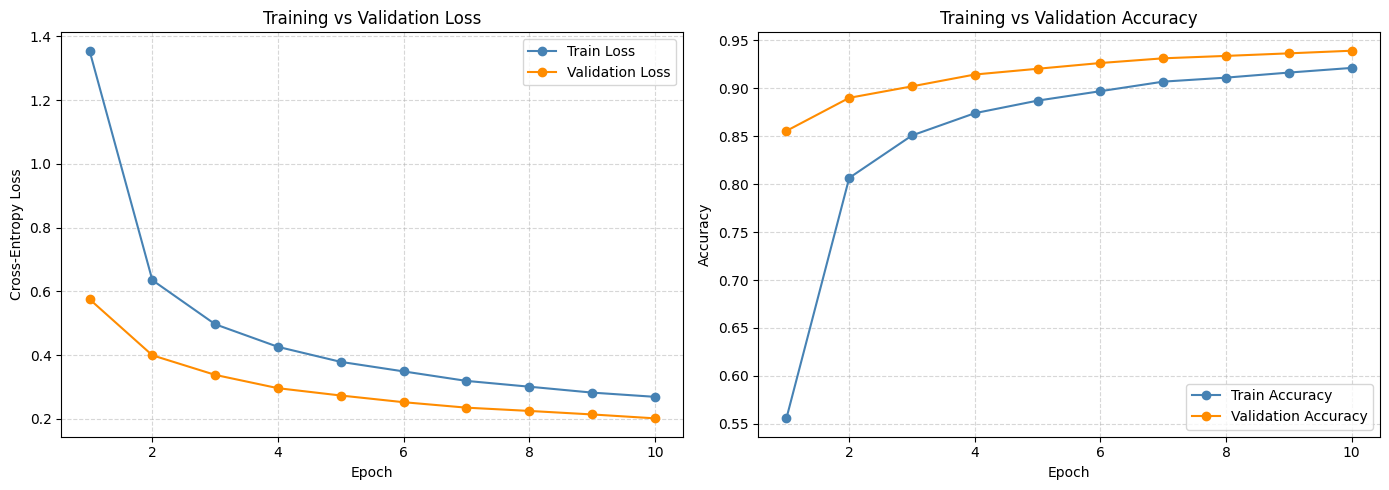

Plot saved → training_curves.png


In [5]:
def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
 
    # — Loss plot —
    ax1.plot(epochs, history["train_loss"], label="Train Loss",      color="steelblue",  marker="o")
    ax1.plot(epochs, history["val_loss"],   label="Validation Loss", color="darkorange", marker="o")
    ax1.set_title("Training vs Validation Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Cross-Entropy Loss")
    ax1.legend()
    ax1.grid(True, linestyle="--", alpha=0.5)
 
    # — Accuracy plot —
    ax2.plot(epochs, history["train_acc"], label="Train Accuracy",      color="steelblue",  marker="o")
    ax2.plot(epochs, history["val_acc"],   label="Validation Accuracy", color="darkorange", marker="o")
    ax2.set_title("Training vs Validation Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.legend()
    ax2.grid(True, linestyle="--", alpha=0.5)
 
    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150)
    plt.show()
    print("Plot saved → training_curves.png")
 
 
# ─────────────────────────────────────────────
# 6. RUN EVERYTHING
# ─────────────────────────────────────────────
if __name__ == "__main__":
    model   = digit_recognition()
    history = model.training_step( train_dataloader, val_dataloader, epochs=10, lr=0.01)
    plot_history(history)


#Imagine you have 1,000 images and a Batch Size of 100.
#To complete 1 Epoch, the model needs to process 10 Batches.
#This means 1 Epoch = 10 Iterations.

# Analysis

In [ ]:
# Model Evaluation
from sklearn.metrics import confusion_matrix, accuracy_score
# evaluates the trained model on unseen test data using: Accuracy & Confusion Matrix
def evaluate_on_test(model, test_loader): 
    y_true = [] # stores actual labels
    y_pred = [] # stores predicted labels
#Dropout is a technique where random neurons are temporarily deactivated during training to prevent overfitting and improve the model’s ability to generalize.
    model.eval() #Disables dropout and training-specific behavior -> عشان اطلع احسن توقع 
    with torch.no_grad():
        for x, y in test_loader:
            outputs = model(x)
            preds = outputs.argmax(dim=1) #argmax selects the class with highest score
            # Store results
            y_true.extend(y.numpy())
            y_pred.extend(preds.numpy())
    # Measures percentage of correct predictions (Accuracy)
    acc = accuracy_score(y_true, y_pred)
    print(f"Test Accuracy: {acc:.4f}")
    # Shows classification errors between classes
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return acc

In [ ]:
# Analyze how different learning rates affect training performance and convergence.
def experiment_learning_rates(lrs, epochs=10):
    results = {}

    for lr in lrs:
        print(f"\n-Training with LR = {lr}")
        # Initializing a new model ensures fair comparison by starting each experiment from scratch without influence from previous training.
        model = digit_recognition()
        # Train model
        history = model.training_step(train_dataloader, val_dataloader, epochs=epochs, lr=lr)
        plot_history(history)
        final_val_acc = history["val_acc"][-1]  # Store only the final val accuracy for the summary bar chart
        results[lr] = final_val_acc
     # ── Summary bar chart: final val accuracy across all learning rates ──
    plt.figure(figsize=(7, 4))
    plt.bar([str(lr) for lr in lrs], [results[lr] for lr in lrs], color="steelblue")
    plt.title("Final Validation Accuracy vs Learning Rate")
    plt.xlabel("Learning Rate")
    plt.ylabel("Validation Accuracy")
    plt.ylim(0, 1)
    for i, lr in enumerate(lrs):
        plt.text(i, results[lr] + 0.01, f"{results[lr]:.4f}", ha="center", fontsize=9)
    plt.tight_layout()
    plt.show()
    return results

## Learning Rate Analysis — Insights

- **High LR (0.1):** Converges fastest in the first few epochs but the loss curve tends to oscillate or even diverge because the weight updates overshoot the minimum.
- **Default LR (0.01):** Good balance — steady convergence, stable loss curve, strong final accuracy.
- **Low LR (0.001):** Converges smoothly but more slowly; may need more epochs to reach peak accuracy.
- **Very low LR (0.0001):** Barely moves in 10 epochs — the steps are too tiny. Loss stays high and accuracy lags far behind. This is classic underfitting due to insufficient learning.

**Takeaway:** LR=0.01 is typically the sweet spot for SGD on MNIST with this architecture.



In [19]:
lr_results = experiment_learning_rates([0.1, 0.01, 0.001, 0.0001])
print(lr_results)


-Training with LR = 0.1
Epoch  0/10 | Train Loss: 0.5794  Acc: 0.8187 | Val Loss: 0.2697  Acc: 0.9183
Epoch  1/10 | Train Loss: 0.2696  Acc: 0.9211 | Val Loss: 0.1890  Acc: 0.9425
Epoch  2/10 | Train Loss: 0.2110  Acc: 0.9379 | Val Loss: 0.1583  Acc: 0.9519
Epoch  3/10 | Train Loss: 0.1725  Acc: 0.9490 | Val Loss: 0.1345  Acc: 0.9607
Epoch  4/10 | Train Loss: 0.1521  Acc: 0.9541 | Val Loss: 0.1294  Acc: 0.9613
Epoch  5/10 | Train Loss: 0.1352  Acc: 0.9592 | Val Loss: 0.1198  Acc: 0.9653
Epoch  6/10 | Train Loss: 0.1258  Acc: 0.9611 | Val Loss: 0.1171  Acc: 0.9636
Epoch  7/10 | Train Loss: 0.1151  Acc: 0.9641 | Val Loss: 0.1129  Acc: 0.9670
Epoch  8/10 | Train Loss: 0.1042  Acc: 0.9672 | Val Loss: 0.1061  Acc: 0.9678
Epoch  9/10 | Train Loss: 0.0931  Acc: 0.9704 | Val Loss: 0.1275  Acc: 0.9649

-Training with LR = 0.01
Epoch  0/10 | Train Loss: 1.3752  Acc: 0.5541 | Val Loss: 0.5558  Acc: 0.8484
Epoch  1/10 | Train Loss: 0.6351  Acc: 0.8046 | Val Loss: 0.3870  Acc: 0.8912
Epoch  2/10 |

In [ ]:
# Study how batch size affects training stability and generalization
def experiment_batch_sizes(batch_sizes, epochs=10):
    results = {}

    for bs in batch_sizes:
        print(f"\n-Training with Batch Size = {bs}")

        train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=bs)

        model = digit_recognition()
        history = model.training_step(train_loader, val_loader, epochs=epochs, lr=0.01)
        
        # Full training curves for this batch size
        plot_history(history, title_suffix=f"Batch={bs}")
        final_val_acc = history["val_acc"][-1]
        results[bs] = final_val_acc
     # ── Summary bar chart ──
    plt.figure(figsize=(7, 4))
    plt.bar([str(bs) for bs in batch_sizes], [results[bs] for bs in batch_sizes], color="darkorange")
    plt.title("Final Validation Accuracy vs Batch Size")
    plt.xlabel("Batch Size")
    plt.ylabel("Validation Accuracy")
    plt.ylim(0, 1)
    for i, bs in enumerate(batch_sizes):
        plt.text(i, results[bs] + 0.01, f"{results[bs]:.4f}", ha="center", fontsize=9)
    plt.tight_layout()
    plt.show()
    return results

## Batch Size Analysis — Insights

- **Small batches (16, 32):** Each gradient update is computed from fewer samples, so the gradient estimate is noisier. This noise acts as implicit regularisation and often leads to better generalisation (higher val accuracy). However, training takes longer per epoch because there are more weight updates.
- **Medium batch (64):** Standard choice — good balance between speed and gradient quality.
- **Large batch (128):** Gradient estimates are very accurate (computed over many samples), so the loss curve is smooth. But the model tends to converge to "sharper" minima that generalise slightly worse. Each epoch is also faster because there are fewer updates.

**Takeaway:** Batch size 32 or 64 typically gives the best generalisation on MNIST with SGD.


In [14]:
bs_results = experiment_batch_sizes([16, 32, 64, 128])
print(bs_results)


-Training with Batch Size = 16
Epoch  0/10 | Train Loss: 0.8146  Acc: 0.7377 | Val Loss: 0.3308  Acc: 0.9067
Epoch  1/10 | Train Loss: 0.3682  Acc: 0.8882 | Val Loss: 0.2425  Acc: 0.9274
Epoch  2/10 | Train Loss: 0.2893  Acc: 0.9144 | Val Loss: 0.2022  Acc: 0.9407
Epoch  3/10 | Train Loss: 0.2388  Acc: 0.9281 | Val Loss: 0.1810  Acc: 0.9453
Epoch  4/10 | Train Loss: 0.2110  Acc: 0.9363 | Val Loss: 0.1652  Acc: 0.9520
Epoch  5/10 | Train Loss: 0.1870  Acc: 0.9437 | Val Loss: 0.1506  Acc: 0.9562
Epoch  6/10 | Train Loss: 0.1719  Acc: 0.9474 | Val Loss: 0.1385  Acc: 0.9601
Epoch  7/10 | Train Loss: 0.1576  Acc: 0.9517 | Val Loss: 0.1335  Acc: 0.9608
Epoch  8/10 | Train Loss: 0.1485  Acc: 0.9546 | Val Loss: 0.1279  Acc: 0.9633
Epoch  9/10 | Train Loss: 0.1371  Acc: 0.9583 | Val Loss: 0.1251  Acc: 0.9641

-Training with Batch Size = 32
Epoch  0/10 | Train Loss: 1.1098  Acc: 0.6394 | Val Loss: 0.4172  Acc: 0.8789
Epoch  1/10 | Train Loss: 0.4756  Acc: 0.8552 | Val Loss: 0.3019  Acc: 0.9108


In [ ]:
# Evaluate the impact of changing both neuron count and number of layers.
#
# CustomNet now accepts a list of hidden sizes of any length, so we can test
# both different widths (neuron counts) and different depths (number of layers)
# in the same class without any changes.

class CustomNet(nn.Module):
    def __init__(self, hidden_sizes):
        """
        hidden_sizes : list of ints, e.g. [128, 64, 32]
                       → builds one hidden layer per element, then a 10-class output.
        """
        super().__init__()
        layers = []
        in_size = 784
        for h in hidden_sizes:
            layers.append(nn.Linear(in_size, h))
            layers.append(nn.ReLU())
            in_size = h
        layers.append(nn.Linear(in_size, 10))   # output layer
        self.model    = nn.Sequential(*layers)
        self.loss_fn  = nn.CrossEntropyLoss()

    def forward(self, x):
        return self.model(x)

    def training_step(self, train_loader, val_loader, epochs, lr=0.01):
        optimizer = optim.SGD(self.parameters(), lr=lr)
        # ← now tracks ALL 4 metrics so plot_history() works correctly
        history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

        for epoch in range(epochs):
            # ── Training phase ──
            self.train()
            running_loss, correct, total = 0.0, 0, 0
            for x, y in train_loader:
                optimizer.zero_grad()
                out  = self(x)
                loss = self.loss_fn(out, y)
                loss.backward()
                optimizer.step()
                running_loss += loss.item() * y.size(0)
                correct      += (out.argmax(dim=1) == y).sum().item()
                total        += y.size(0)
            train_loss = running_loss / total
            train_acc  = correct / total

            # ── Validation phase ──
            self.eval()
            val_loss_sum, val_correct, val_total = 0.0, 0, 0
            with torch.no_grad():
                for x, y in val_loader:
                    out  = self(x)
                    loss = self.loss_fn(out, y)
                    val_loss_sum += loss.item() * y.size(0)
                    val_correct  += (out.argmax(dim=1) == y).sum().item()
                    val_total    += y.size(0)
            val_loss = val_loss_sum / val_total
            val_acc  = val_correct  / val_total

            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["train_acc"].append(train_acc)
            history["val_acc"].append(val_acc)

            print(f"Epoch {epoch:>2}/{epochs} | "
                  f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}")

        return history


# ── Experiment A: vary neuron WIDTH (keep depth fixed at 3 hidden layers) ──
def experiment_neurons(configs, label="neurons"):
    results = {}
    for sizes in configs:
        label_str = str(sizes)
        print(f"\n--- Architecture: {label_str} ---")
        model   = CustomNet(sizes)
        history = model.training_step(train_dataloader, val_dataloader, epochs=10)
        plot_history(history, title_suffix=f"Arch {label_str}")
        results[label_str] = history["val_acc"][-1]

    # Summary bar chart
    plt.figure(figsize=(9, 4))
    plt.bar(list(results.keys()), list(results.values()), color="seagreen")
    plt.title(f"Final Val Accuracy vs Architecture ({label})")
    plt.xlabel("Hidden Layer Sizes")
    plt.ylabel("Validation Accuracy")
    plt.ylim(0, 1)
    for i, (k, v) in enumerate(results.items()):
        plt.text(i, v + 0.01, f"{v:.4f}", ha="center", fontsize=8)
    plt.tight_layout()
    plt.show()
    return results


# ── Neuron width experiment (depth = 3 hidden layers, width changes) ──
width_configs = [
    [64,  32,  16],
    [128, 64,  32],
    [256, 128, 64],
    [512, 256, 128],
]
width_results = experiment_neurons(width_configs, label="width")
print("Width results:", width_results)


# ── Depth experiment (width ≈ fixed ~128, number of hidden layers changes) ──
depth_configs = [
    [128],                    # 1 hidden layer
    [128, 64],                # 2 hidden layers
    [128, 64, 32],            # 3 hidden layers
    [128, 64, 32, 16],        # 4 hidden layers
]
depth_results = experiment_neurons(depth_configs, label="depth")
print("Depth results:", depth_results)


## Architecture Analysis — Insights

### Neuron Width (fixed 3 layers, changing neuron count)
- **Narrow networks [64,32,16]:** Limited capacity → underfits slightly; the bottleneck at 16 neurons before the output forces too much compression.
- **Medium [128,64,32]:** Usually the sweet spot on MNIST — enough capacity without wasting computation.
- **Wide [256,128,64] and [512,256,128]:** Marginal or no improvement over medium on MNIST because the task is not complex enough to need that many parameters. Training may also be slightly slower.

### Network Depth (fixed width ≈128, changing number of layers)
- **1 hidden layer:** Can still reach decent accuracy on MNIST (it is a simple dataset), but it misses some feature hierarchies.
- **2–3 hidden layers:** Better feature abstraction; generally higher accuracy.
- **4 hidden layers:** On simple tasks like MNIST, very deep networks with SGD can sometimes train slower because gradients weaken as they travel back through many layers (vanishing gradient). ReLU helps, but it does not fully eliminate the issue.

**Takeaway:** 2–3 hidden layers with medium width (128→64→32) is the most efficient architecture for this task.



Increasing neurons improves performance slightly

MNIST is simple → large networks not necessary

In [ ]:
def experiment_neurons(configs):
    results = {}

    for (h1, h2, h3) in configs:
        print(f"\n-Layers: {h1}, {h2}, {h3}")

        model = CustomNet(h1, h2, h3)
        history = model.training_step(train_dataloader, val_dataloader, epochs=10)

        results[(h1, h2, h3)] = history["val_acc"][-1]

    return results

configs = [(64,32,16), (128,64,32), (256,128,64), (512,256,128)]
neuron_results = experiment_neurons(configs)

print(neuron_results)


-Layers: 64, 32, 16

-Layers: 128, 64, 32

-Layers: 256, 128, 64

-Layers: 512, 256, 128
{(64, 32, 16): 0.9089166666666667, (128, 64, 32): 0.9095833333333333, (256, 128, 64): 0.91325, (512, 256, 128): 0.91725}


## Best Model — Final Evaluation on Test Set

Epoch  0/10 | Train Loss: 1.3224  Acc: 0.5742 | Val Loss: 0.5915  Acc: 0.8412
Epoch  1/10 | Train Loss: 0.6402  Acc: 0.8045 | Val Loss: 0.4004  Acc: 0.8883
Epoch  2/10 | Train Loss: 0.4928  Acc: 0.8521 | Val Loss: 0.3336  Acc: 0.9056
Epoch  3/10 | Train Loss: 0.4202  Acc: 0.8734 | Val Loss: 0.2977  Acc: 0.9146
Epoch  4/10 | Train Loss: 0.3703  Acc: 0.8881 | Val Loss: 0.2701  Acc: 0.9204
Epoch  5/10 | Train Loss: 0.3366  Acc: 0.9007 | Val Loss: 0.2478  Acc: 0.9297
Epoch  6/10 | Train Loss: 0.3165  Acc: 0.9068 | Val Loss: 0.2301  Acc: 0.9339
Epoch  7/10 | Train Loss: 0.2897  Acc: 0.9131 | Val Loss: 0.2186  Acc: 0.9382
Epoch  8/10 | Train Loss: 0.2762  Acc: 0.9187 | Val Loss: 0.2089  Acc: 0.9390
Epoch  9/10 | Train Loss: 0.2560  Acc: 0.9244 | Val Loss: 0.1968  Acc: 0.9429


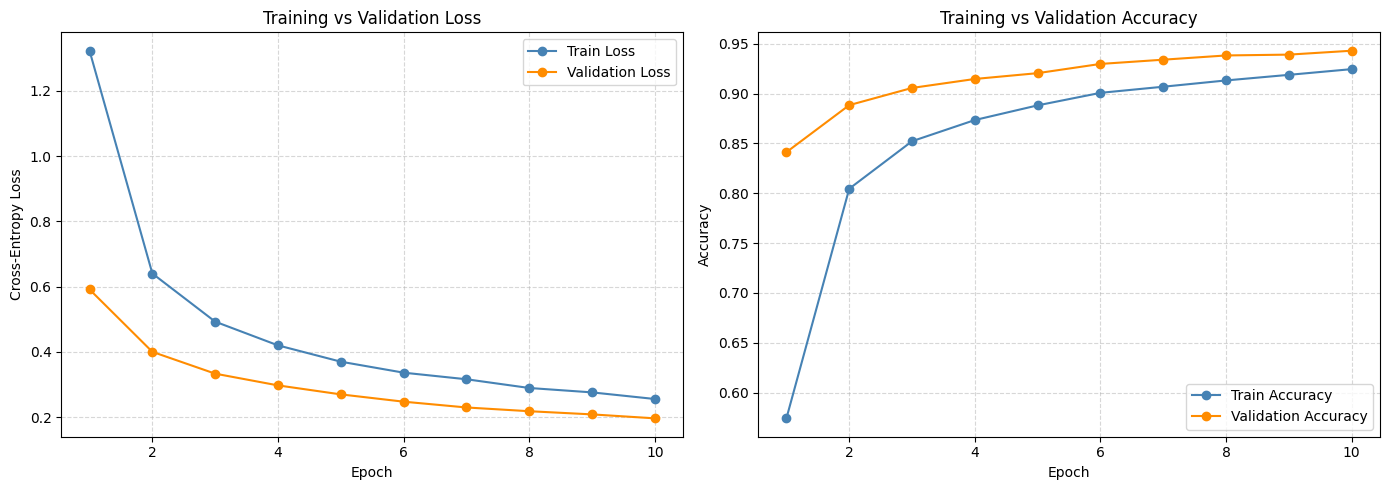

Plot saved → training_curves.png
Test Accuracy: 0.9447


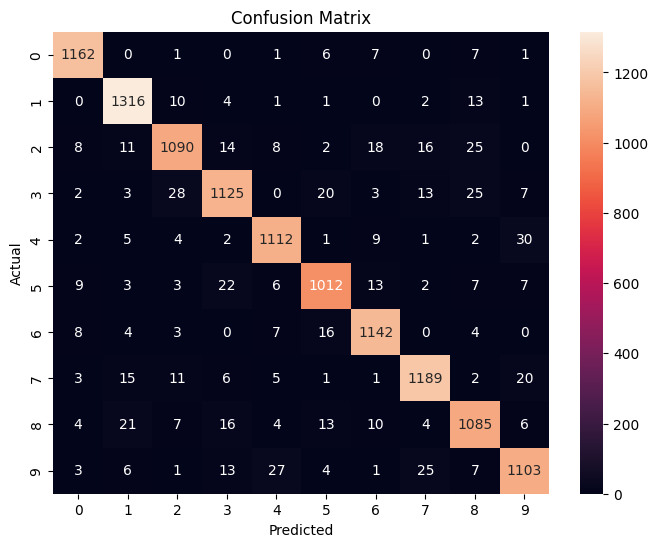

In [ ]:
# Train the best model configuration and evaluate it on test data.
best_model = digit_recognition()
history = best_model.training_step(train_dataloader, val_dataloader, epochs=10, lr=0.01)

plot_history(history)

test_acc = evaluate_on_test(best_model, test_dataloader)